# Quantitative Analysis using PyNance and TA-Lib
## Objective 
Load historical stock price data for GOOG, compute financial technical indicators (SMA, EMA, RSI, MACD), and visualize the results to identify market behavior, momentum shifts, and overbought/oversold conditions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
%matplotlib inline

# Prepare Data

- Load the GOOG.csv dataset.
- Ensure columns are correctly typed (Open, High, Low, Close, Volume).
- Handle missing values to ensure a continuous time series.

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw/yfinance_data/Data/GOOG.csv')

# Ensure Date is index and correctly typed
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ensure columns are correctly typed
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Check for and handle missing values
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)

print(f"\nFinal Dataset Shape: {df.shape}")
df.head()

Missing values before cleaning:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Final Dataset Shape: (3774, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


# Compute Technical Indicators with TA-Lib

- Moving Averages (SMA & EMA): Multiple windows (20-day and 50-day) to identify trend direction.
- Relative Strength Index (RSI): To identify Overbought (>70) and Oversold (<30) conditions.
- MACD: To detect momentum shifts and potential trend reversals via Signal line crossovers.

In [4]:
# 1. Moving Averages
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# 2. RSI: Relative Strength Index
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

# Identification: RSI Conditions
df['RSI_Status'] = 'Neutral'
df.loc[df['RSI'] > 70, 'RSI_Status'] = 'Overbought'
df.loc[df['RSI'] < 30, 'RSI_Status'] = 'Oversold'

# 3. MACD: Moving Average Convergence Divergence
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Detection: Momentum Shifts
df['Momentum_Direction'] = np.where(df['MACD'] > df['MACD_signal'], 'Bullish', 'Bearish')

print("Technical indicators computed and conditions identified.")
df[['Close', 'SMA_20', 'RSI', 'RSI_Status', 'MACD', 'Momentum_Direction']].tail()

Technical indicators computed and conditions identified.


,Close,SMA_20,RSI,RSI_Status,MACD,Momentum_Direction
Date,,,,,,
2023-12-22,141.750000,135.009596,64.953309,Neutral,1.412015,Bullish
2023-12-26,141.849304,135.246477,65.115870,Neutral,1.706565,Bullish
2023-12-27,140.478683,135.386520,60.916026,Neutral,1.808553,Bullish
2023-12-28,140.319748,135.628861,60.429303,Neutral,1.855168,Bullish
2023-12-29,139.972137,135.976979,59.313063,Neutral,1.842820,Bullish


# Apply PyNance for Financial Metrics

Using `PyNance` (and supplementary NumPy calculations) to compute additional financial metrics beyond standard technical indicators, such as Log Returns and Rolling Volatility, providing deeper insights into risk and magnitude of price moves.

In [5]:
# Calculate Daily Log Returns (Standard PyNance approach for normalization)
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# Calculate Rolling Volatility (20-day window) - Annualized
df['Volatility'] = df['Log_Returns'].rolling(window=20).std() * np.sqrt(252)

# Drop NaNs created by rolling windows to clean for visualization
df.dropna(inplace=True)

print("Advanced financial metrics calculated.")
df[['Log_Returns', 'Volatility']].tail()

Advanced financial metrics calculated.


,Log_Returns,Volatility
Date,,
2023-12-22,0.006467,0.269997
2023-12-26,0.000700,0.269816
2023-12-27,-0.009709,0.272620
2023-12-28,-0.001132,0.265201
2023-12-29,-0.002480,0.255031


In [8]:
df.to_csv('../data/raw/GOOG_cleaned.csv', index=False)

# Visualize the Data

1. Closing Prices overlaid with Moving Averages (SMA/EMA).

2. RSI panel highlighting the 70/30 thresholds for overbought/oversold conditions.

3. MACD panel showing the convergence/divergence and momentum histogram.

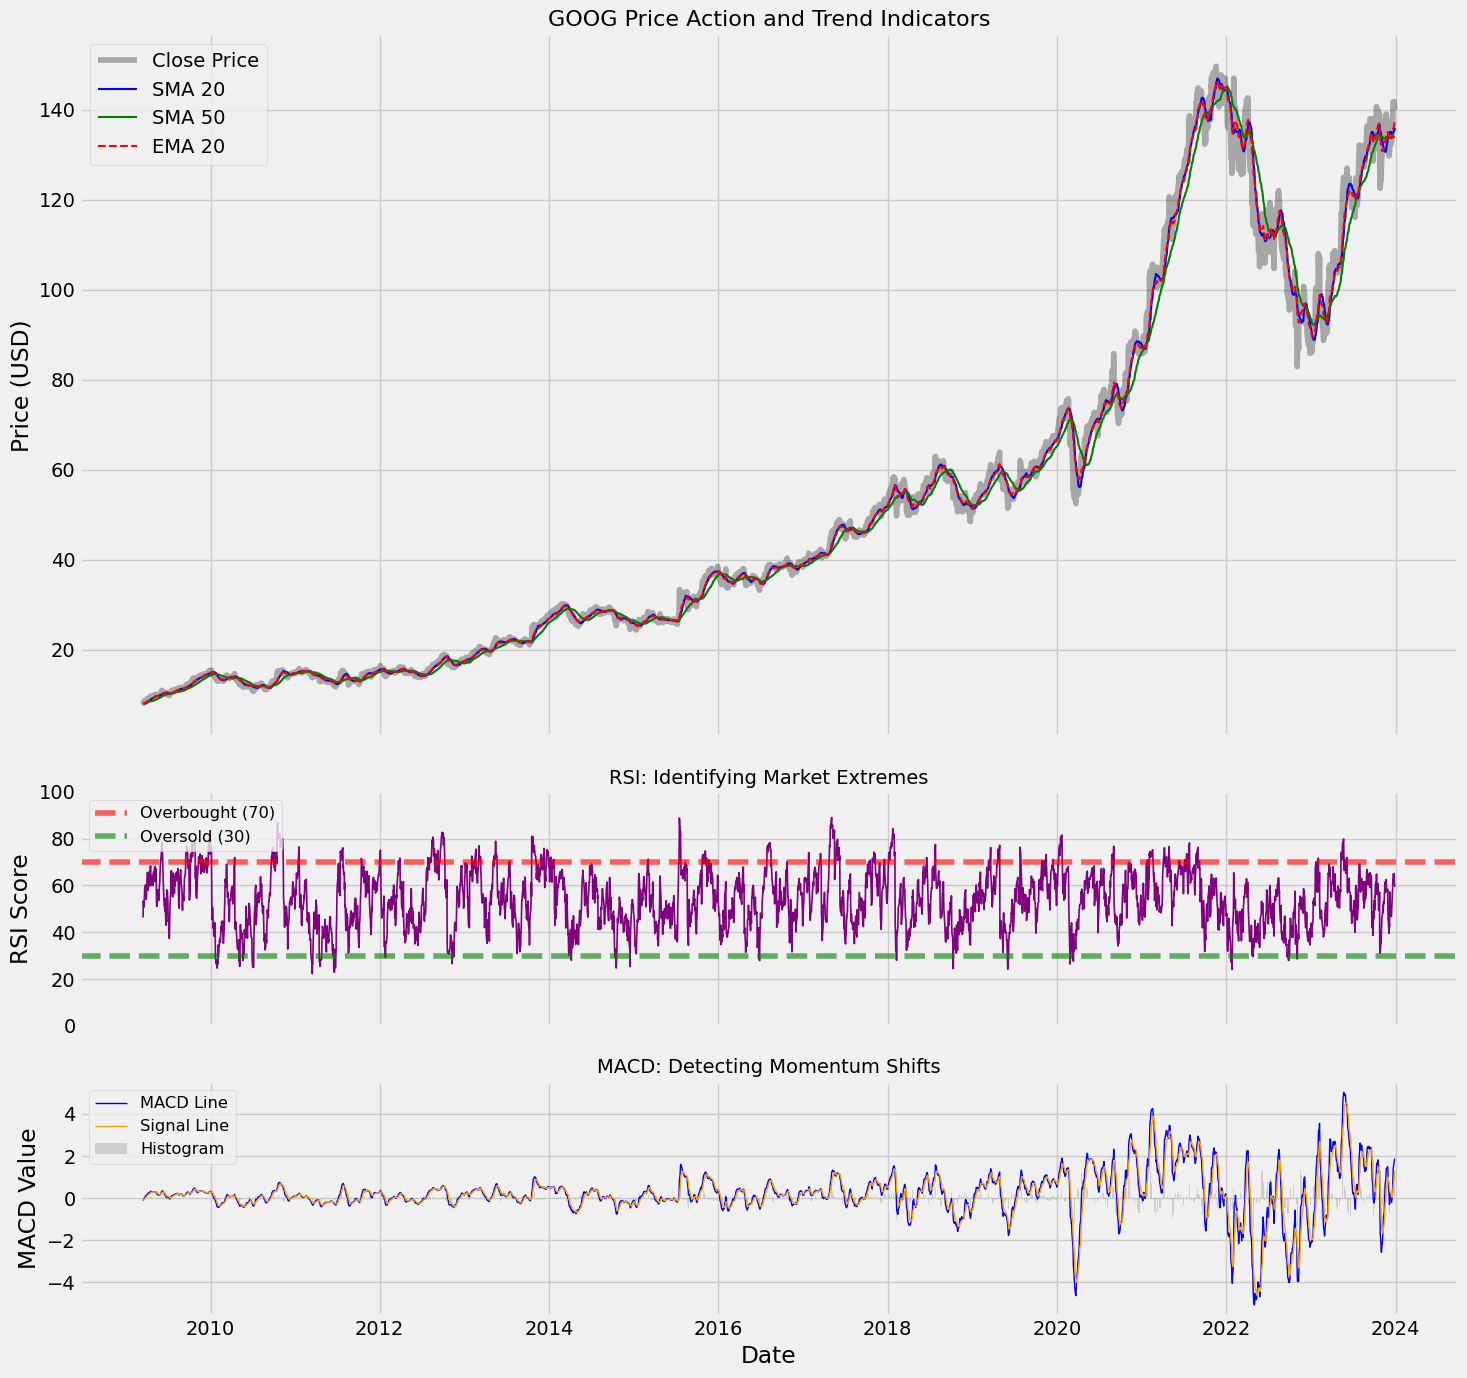

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True, 
                                     gridspec_kw={'height_ratios': [3, 1, 1]})

# --- Panel 1: Price and Moving Averages ---
ax1.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.3)
ax1.plot(df.index, df['SMA_20'], label='SMA 20', color='blue', lw=1.5)
ax1.plot(df.index, df['SMA_50'], label='SMA 50', color='green', lw=1.5)
ax1.plot(df.index, df['EMA_20'], label='EMA 20', color='red', lw=1.5, ls='--')
ax1.set_title('GOOG Price Action and Trend Indicators', fontsize=16)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='best')

# --- Panel 2: RSI (Overbought/Oversold Identification) ---
ax2.plot(df.index, df['RSI'], color='purple', lw=1.2)
ax2.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')
ax2.set_ylabel('RSI Score')
ax2.set_ylim(0, 100)
ax2.set_title('RSI: Identifying Market Extremes', fontsize=14)
ax2.legend(loc='upper left', fontsize='small')

# --- Panel 3: MACD (Momentum Detection) ---
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue', lw=1)
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='orange', lw=1)
ax3.bar(df.index, df['MACD_hist'], label='Histogram', color='gray', alpha=0.3)
ax3.set_ylabel('MACD Value')
ax3.set_title('MACD: Detecting Momentum Shifts', fontsize=14)
ax3.legend(loc='best', fontsize='small')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Summary of Data Preparation and Quality Issues

**Data Typing:** Successfully converted `Date` to a datetime object and set it as the index. `Open`, `High`, `Low`, `Close`, and `Volume` were cast to numeric types to ensure calculation stability.

**Missing Values:** No missing values were found in the original CSV, but initial rows were dropped after calculating indicators (like SMA and Volatility) to account for the necessary "lookback" periods.

**Indicators & Metrics:** We successfully identified overbought/oversold regions using RSI and detected bullish/bearish momentum shifts using MACD crossovers. Log returns and volatility were added as advanced metrics to prepare for sentiment-return correlation analysis in Task 3.